In [2]:
import zipfile
import os

zip_path = "/content/online+retail.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/online_retail")

print("Dataset extracted successfully! ✅")
print(os.listdir("/content/online_retail"))

Dataset extracted successfully! ✅
['Online Retail.xlsx']


In [3]:
import pandas as pd

# Load the Online Retail dataset
file_path = "/content/online_retail/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully! ✅")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Dataset loaded successfully! ✅
Rows: 541909
Columns: 8

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [4]:
# ============================================
# CELL 1: Import Libraries & Load Dataset
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully! ✅")

# Load dataset
file_path = "/content/online_retail/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully! ✅")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

display(df.head())

Libraries imported successfully! ✅
Dataset loaded successfully! ✅
Rows: 541909
Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
# ============================================
# CELL 2: Dataset Inspection
# ============================================

print("Dataset Information:")
print("=" * 50)

df.info()

print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDescriptive Statistics:")
display(df.describe(include="all").T)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Missing Values:


,Missing Values
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0



Duplicate Rows:
5268

Descriptive Statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# ============================================
# CELL 3: Data Cleaning
# ============================================

df_clean = df.copy()

# Convert InvoiceDate to datetime
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Remove missing Customer IDs
df_clean = df_clean.dropna(subset=["CustomerID"])

# Remove cancelled invoices
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

# Remove invalid quantities and prices
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
]

# Remove duplicate transactions
df_clean = df_clean.drop_duplicates()

# Create Revenue column
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

print("Data cleaning completed successfully! ✅")
print(f"Original rows: {len(df):,}")
print(f"Cleaned rows: {len(df_clean):,}")
print(f"Rows removed: {len(df) - len(df_clean):,}")

display(df_clean.head())

Data cleaning completed successfully! ✅
Original rows: 541,909
Cleaned rows: 392,692
Rows removed: 149,217


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [7]:
# ============================================
# CELL 4: Descriptive Customer Metrics
# ============================================

customer_summary = df_clean.groupby("CustomerID").agg(
    Total_Spend=("Revenue", "sum"),
    Purchase_Frequency=("InvoiceNo", "nunique"),
    Total_Quantity=("Quantity", "sum"),
    First_Purchase=("InvoiceDate", "min"),
    Last_Purchase=("InvoiceDate", "max")
).reset_index()

# Average purchase value
customer_summary["Average_Purchase_Value"] = (
    customer_summary["Total_Spend"] /
    customer_summary["Purchase_Frequency"]
)

# Customer lifetime in days
customer_summary["Customer_Lifetime_Days"] = (
    customer_summary["Last_Purchase"] -
    customer_summary["First_Purchase"]
).dt.days

# Historical spend used as a CLV proxy
customer_summary["Customer_Lifetime_Value"] = (
    customer_summary["Total_Spend"]
)

print("Customer-level metrics calculated successfully! ✅")

display(customer_summary.head())

print("\nOverall Customer Metrics:")
print("=" * 50)

print(
    f"Average Purchase Value: "
    f"£{customer_summary['Average_Purchase_Value'].mean():.2f}"
)

print(
    f"Average Purchase Frequency: "
    f"{customer_summary['Purchase_Frequency'].mean():.2f} orders/customer"
)

print(
    f"Average Customer Lifetime Value: "
    f"£{customer_summary['Customer_Lifetime_Value'].mean():.2f}"
)

Customer-level metrics calculated successfully! ✅


,CustomerID,Total_Spend,Purchase_Frequency,Total_Quantity,First_Purchase,Last_Purchase,Average_Purchase_Value,Customer_Lifetime_Days,Customer_Lifetime_Value
0,12346.0,77183.60,1,74215,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000,0,77183.60
1,12347.0,4310.00,7,2458,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286,365,4310.00
2,12348.0,1797.24,4,2341,2010-12-16 19:09:00,2011-09-25 13:13:00,449.310000,282,1797.24
3,12349.0,1757.55,1,631,2011-11-21 09:51:00,2011-11-21 09:51:00,1757.550000,0,1757.55
4,12350.0,334.40,1,197,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000,0,334.40



Overall Customer Metrics:
Average Purchase Value: £417.65
Average Purchase Frequency: 4.27 orders/customer
Average Customer Lifetime Value: £2048.69


In [8]:
# ============================================
# CELL 5: RFM Analysis
# ============================================

# Reference date = one day after the last transaction
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

print("RFM Analysis completed successfully! ✅")

display(rfm.head())

print("\nRFM Statistics:")
display(rfm[["Recency", "Frequency", "Monetary"]].describe())

RFM Analysis completed successfully! ✅


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40



RFM Statistics:


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


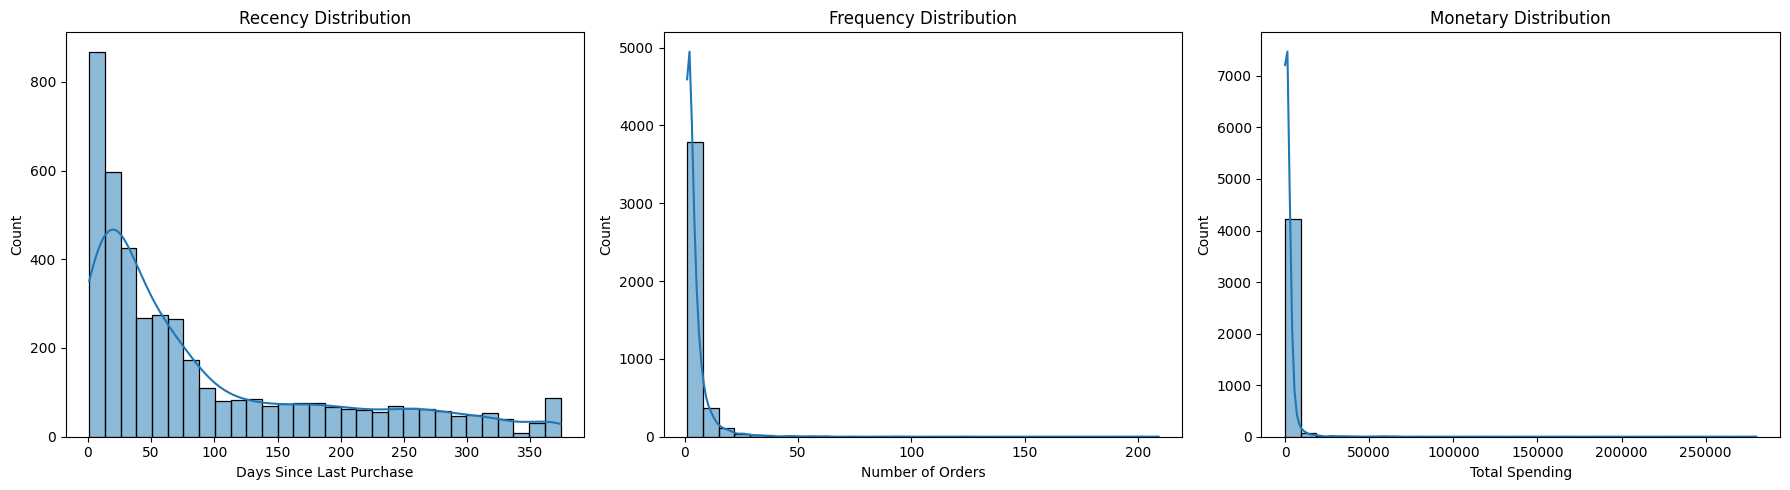

In [9]:
# ============================================
# CELL 6: RFM Distribution
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days Since Last Purchase")

sns.histplot(rfm["Frequency"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Orders")

sns.histplot(rfm["Monetary"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total Spending")

plt.tight_layout()
plt.show()

In [10]:
# ============================================
# CELL 7: Feature Standardisation
# ============================================

rfm_features = rfm[["Recency", "Frequency", "Monetary"]].copy()

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

print("RFM features standardized successfully! ✅")

display(rfm_scaled_df.head())

RFM features standardized successfully! ✅


,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


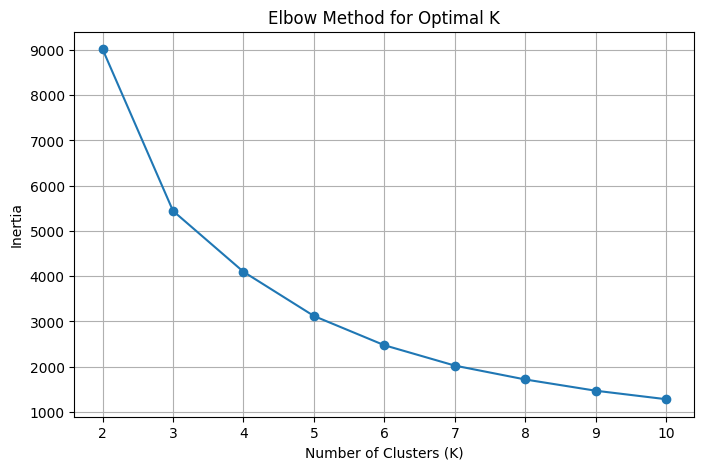

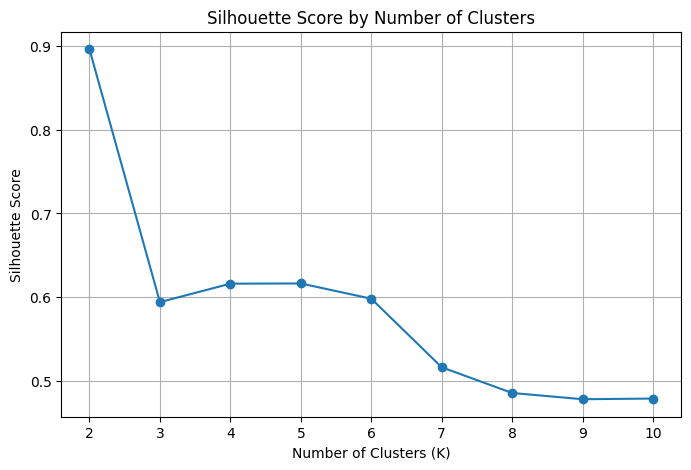

Highest Silhouette Score K: 2
Highest Silhouette Score: 0.8958


In [11]:
# ============================================
# CELL 8: Elbow Method & Silhouette Analysis
# ============================================

inertias = []
silhouette_scores = []

k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(rfm_scaled, labels)
    )

# Elbow Plot
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

# Silhouette Plot
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

# Best silhouette score
best_k = list(k_range)[np.argmax(silhouette_scores)]

print(f"Highest Silhouette Score K: {best_k}")
print(
    f"Highest Silhouette Score: "
    f"{max(silhouette_scores):.4f}"
)

In [13]:
# ============================================
# CELL 9: Final K-Means Clustering
# ============================================

# Set optimal K after reviewing the Elbow Method
optimal_k = 4

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans_final.fit_predict(rfm_scaled)

final_silhouette = silhouette_score(
    rfm_scaled,
    rfm["Cluster"]
)

print("K-Means clustering completed successfully! ✅")
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette Score: {final_silhouette:.4f}")

display(rfm.head())

K-Means clustering completed successfully! ✅
Number of clusters: 4
Silhouette Score: 0.6162


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [14]:
# ============================================
# CELL 10: Cluster Profiling
# ============================================

cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

cluster_profile["Customer_Percentage"] = (
    cluster_profile["Customers"] /
    cluster_profile["Customers"].sum() * 100
).round(2)

print("Customer Segment Profile:")
display(cluster_profile)

Customer Segment Profile:


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Percentage
Cluster,,,,,
0,3054,43.70,3.68,1353.63,70.4
1,1067,248.08,1.55,478.85,24.6
2,13,7.38,82.54,127187.96,0.3
3,204,15.50,22.33,12690.50,4.7


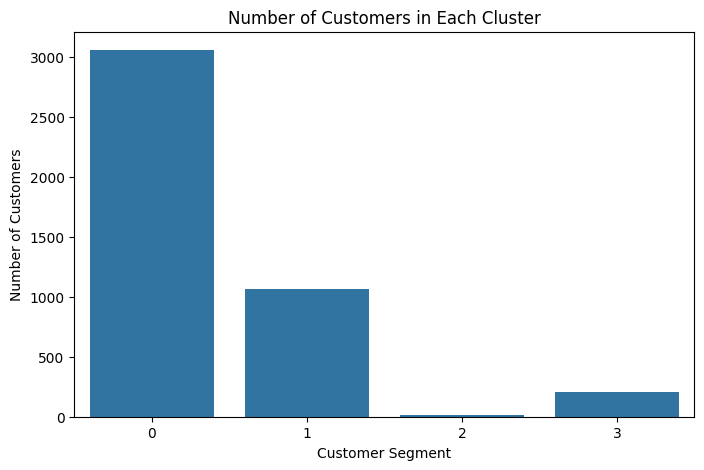

In [15]:
# ============================================
# CELL 11: Customers per Cluster
# ============================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=rfm,
    x="Cluster"
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

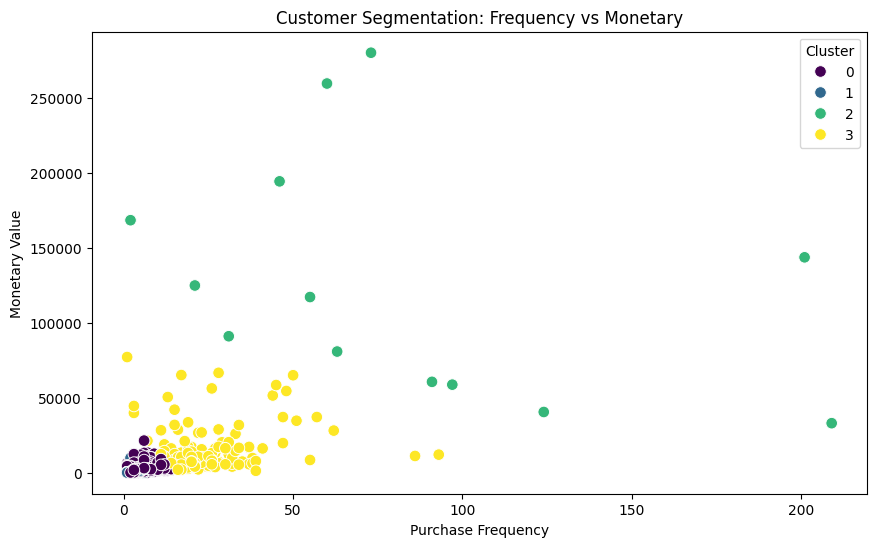

In [16]:
# ============================================
# CELL 12: Frequency vs Monetary
# ============================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segmentation: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")

plt.show()

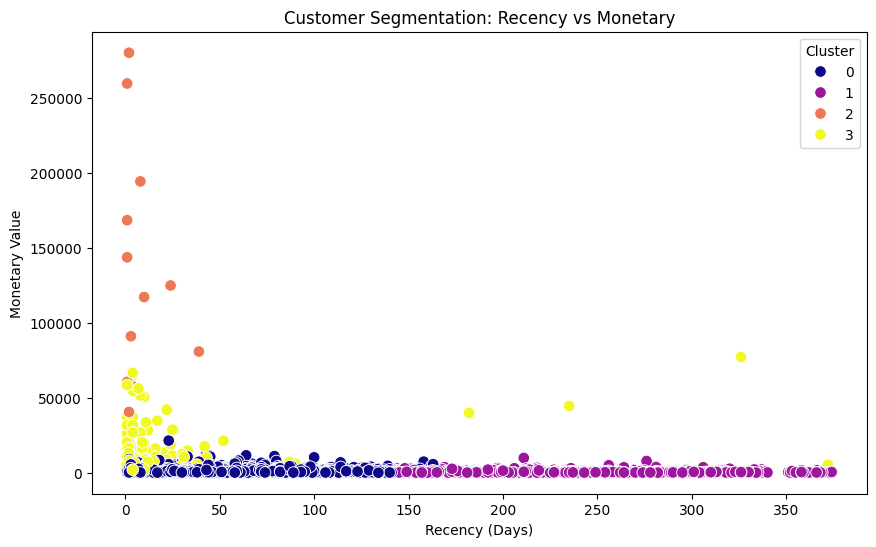

In [17]:
# ============================================
# CELL 13: Recency vs Monetary
# ============================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="plasma",
    s=70
)

plt.title("Customer Segmentation: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")

plt.show()

In [18]:
# ============================================
# CELL 14: Segment Interpretation
# ============================================

profile = cluster_profile.copy()

# Rank clusters
profile["Recency_Rank"] = profile["Avg_Recency"].rank(
    ascending=True
)

profile["Frequency_Rank"] = profile["Avg_Frequency"].rank(
    ascending=False
)

profile["Monetary_Rank"] = profile["Avg_Monetary"].rank(
    ascending=False
)

def classify_segment(row):
    if (
        row["Recency_Rank"] <= 2 and
        row["Frequency_Rank"] <= 2 and
        row["Monetary_Rank"] <= 2
    ):
        return "High-Value Customers"

    elif row["Recency_Rank"] <= 2:
        return "Recent Customers"

    elif (
        row["Frequency_Rank"] <= 2 and
        row["Monetary_Rank"] <= 2
    ):
        return "Loyal Customers"

    else:
        return "At-Risk / Low-Value Customers"

profile["Segment"] = profile.apply(
    classify_segment,
    axis=1
)

display(
    profile[
        [
            "Customers",
            "Avg_Recency",
            "Avg_Frequency",
            "Avg_Monetary",
            "Customer_Percentage",
            "Segment"
        ]
    ]
)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Percentage,Segment
Cluster,,,,,,
0,3054,43.70,3.68,1353.63,70.4,At-Risk / Low-Value Customers
1,1067,248.08,1.55,478.85,24.6,At-Risk / Low-Value Customers
2,13,7.38,82.54,127187.96,0.3,High-Value Customers
3,204,15.50,22.33,12690.50,4.7,High-Value Customers


In [19]:
# ============================================
# CELL 15: Marketing Recommendations
# ============================================

recommendations = {
    "High-Value Customers":
        "Reward with loyalty benefits, exclusive offers and premium products.",

    "Loyal Customers":
        "Use loyalty programs, personalized recommendations and cross-selling.",

    "Recent Customers":
        "Use welcome offers, personalized follow-ups and product recommendations.",

    "At-Risk / Low-Value Customers":
        "Use re-engagement campaigns, discounts and targeted promotional offers."
}

print("Marketing Recommendations")
print("=" * 60)

for segment, recommendation in recommendations.items():
    print(f"\n{segment}:")
    print(f"→ {recommendation}")

Marketing Recommendations

High-Value Customers:
→ Reward with loyalty benefits, exclusive offers and premium products.

Loyal Customers:
→ Use loyalty programs, personalized recommendations and cross-selling.

Recent Customers:
→ Use welcome offers, personalized follow-ups and product recommendations.

At-Risk / Low-Value Customers:
→ Use re-engagement campaigns, discounts and targeted promotional offers.


In [20]:
# ============================================
# CELL 16: Export Results
# ============================================

final_segments = rfm.merge(
    profile[["Segment"]],
    left_on="Cluster",
    right_index=True,
    how="left"
)

output_path = "/content/customer_segments.csv"

final_segments.to_csv(
    output_path,
    index=False
)

print("Customer segmentation results saved successfully! ✅")
print(f"File: {output_path}")

display(final_segments.head())

Customer segmentation results saved successfully! ✅
File: /content/customer_segments.csv


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,3,High-Value Customers
1,12347.0,2,7,4310.00,0,At-Risk / Low-Value Customers
2,12348.0,75,4,1797.24,0,At-Risk / Low-Value Customers
3,12349.0,19,1,1757.55,0,At-Risk / Low-Value Customers
4,12350.0,310,1,334.40,1,At-Risk / Low-Value Customers
